In [1]:
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
corpora = pd.read_parquet("../../corpora/GeneratedCorpus/corpora_v3.parquet")
corpora = corpora.reset_index(names='text_id')


results = pd.DataFrame()
for res in glob("./results/*"):
    temp = pd.read_csv(res)
    temp["model"] = res.split("/")[-1].replace(".csv", "")
    results = pd.concat([results, temp])


df = pd.merge(results, corpora)


# df = df[~df["scenario"].isin(["GRAMMAR SWAP", "GRAMMAR SWAP v2"])]
df = df[df["language"].isin(["INGLÊS", "PB NATIVO"])]

**As análises foram feitas em cima do INGLÊS e PB NATIVO por possuir todas as sentenças**

# Analise das perplexidades e BPB dos modelos

In [3]:
df.groupby(["model"])["ppl"].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Sabia 7B,598.00,20.56,19.09,2.24,9.04,13.06,23.87,147.77
Gemma4-12B,598.00,45.58,68.12,3.50,13.66,21.52,40.31,556.14
Qwen3.5-9B,598.00,50.43,74.58,3.90,15.08,24.21,44.10,550.20
Qwen3.5-9B-it,598.00,58.22,86.05,4.11,16.62,27.40,53.07,656.73
Cabrita,598.00,59.96,81.00,4.39,20.22,32.61,57.48,593.76
Tucano-2b4,598.00,83.15,141.10,2.56,15.87,31.06,64.01,974.30
Tucano-2b4-it,598.00,87.82,151.21,2.67,16.24,32.35,66.82,1077.84
Manaca,598.00,128.52,226.90,3.57,26.89,45.69,89.38,1669.60
Gemma4-12B-it,598.00,803041004.80,4259597204.78,122.86,57088.08,309594.07,5439484.89,42860415586.44


In [4]:
df.groupby(["model"])["bpb"].describe().sort_values(by='mean')


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Gemma4-12B,598.00,1.11,0.33,0.35,0.88,1.03,1.27,2.09
Qwen3.5-9B,598.00,1.14,0.33,0.42,0.90,1.07,1.29,2.13
Qwen3.5-9B-it,598.00,1.18,0.35,0.44,0.92,1.11,1.39,2.16
Sabia 7B,598.00,1.18,0.34,0.31,0.95,1.11,1.36,2.21
Tucano-2b4,598.00,1.25,0.33,0.23,1.02,1.18,1.44,2.22
Tucano-2b4-it,598.00,1.26,0.33,0.24,1.03,1.19,1.46,2.24
Manaca,598.00,1.29,0.32,0.30,1.08,1.23,1.48,2.23
Cabrita,598.00,1.31,0.34,0.48,1.08,1.24,1.47,2.27
Gemma4-12B-it,598.00,4.60,1.39,1.51,3.65,4.33,5.20,9.71


Como o Gemma4 apresentou comportamentos anormais, os resultados dos modelos Instruction-Tuned serão desconsiderados

In [5]:
df = df[~df["model"].isin(["Qwen3.5-9B-it", "Tucano-2b4-it", "Gemma4-12B-it"])]

# Quais cenários são mais diferentes para os modelos?

## Análise geral

In [48]:
df.groupby(["scenario"])["ppl"].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
scenario,,,,,,,,
TRANSLATION,492.00,15.64,8.32,4.10,9.52,13.77,19.64,72.81
PB NATIVO,492.00,21.11,15.50,2.24,10.75,16.87,26.78,119.37
GRAMMAR SWAP v2,492.00,27.90,19.81,4.48,13.54,23.76,36.39,166.54
GRAMMAR SWAP v3,492.00,29.26,19.26,3.16,14.25,24.53,37.97,123.68
GRAMMAR SWAP,144.00,29.83,20.12,3.94,15.83,25.54,40.18,153.55
LEXICAL SWAP,492.00,35.11,27.71,6.82,18.58,27.81,42.88,266.05
PB CORRUPTED,492.00,70.95,65.00,6.58,29.58,51.43,87.74,549.36
PB PERMUTED,492.00,263.13,249.51,6.86,82.92,182.84,346.15,1669.60


TRANSLATION e PB NATIVO esperados possuindo as menores perplexidades
- Presença dos multi-língues é o que pode ter feito a TRANSLATION ficar mais baixa

-------

**GRAMMAR SWAP v3** possui perplexidade média e desvio padrão menor que o **LEXICAL SWAP**
- Em geral, para o inglês, os modelos tendem a entender melhor a gramática

**GRAMMAR SWAP v3** vs **GRAMMAR SWAP v2**
- v2 possui uma menor perplexidade média e desvio padrão próximo
- v2 possui muitos textos que se aproximam mais da gramática do português
    - Termo original: ácido oleico
    - Em inglês: oleic acid
    - GRAMMAR SWAP v2: ácido oleico
    - **GRAMMAR SWAP v3: oleico ácido**
        - Está mais de acordo com o que estamos procurando
------

Conjugações verbais incorretas são mais compreensíveis para o modelo do que alteração na ordem das palavras



## Análise por cenário e modelo

### Grammar Swap

In [7]:
v2 = df[df["scenario"] == "GRAMMAR SWAP v2"].groupby(["model"])["ppl"].describe().sort_values(by="mean")
display(v2)

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Sabia 7B,82.00,10.28,3.50,4.48,7.28,9.85,12.81,23.88
Gemma4-12B,82.00,20.31,10.06,8.07,12.99,18.57,25.62,65.30
Qwen3.5-9B,82.00,21.25,9.56,6.92,13.60,19.74,27.08,48.98
Cabrita,82.00,30.60,13.92,5.13,21.54,28.40,37.26,74.41
Tucano-2b4,82.00,36.66,18.07,6.48,23.94,32.96,45.73,94.07
Manaca,82.00,48.33,26.99,12.82,28.88,41.69,58.12,166.54


In [8]:
v3 = df[df["scenario"] == "GRAMMAR SWAP v3"].groupby(["model"])["ppl"].describe().sort_values(by="mean")
display(v3)


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Sabia 7B,82.00,10.71,3.27,3.16,8.23,10.50,12.57,19.94
Gemma4-12B,82.00,20.79,9.53,3.92,12.83,19.76,26.07,49.41
Qwen3.5-9B,82.00,22.10,9.56,3.90,14.19,21.62,27.49,45.98
Cabrita,82.00,31.71,12.80,6.49,22.25,32.05,38.45,69.88
Tucano-2b4,82.00,39.10,17.01,6.98,25.99,36.60,50.27,91.66
Manaca,82.00,51.19,23.23,9.75,34.82,47.82,63.42,123.68


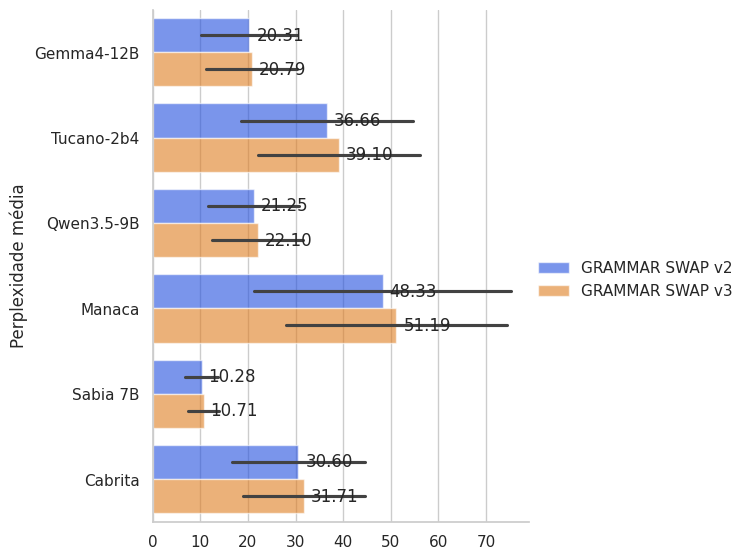

In [9]:
plot_df = df[
    df["scenario"].isin(["GRAMMAR SWAP v2", "GRAMMAR SWAP v3"])
].copy()

g = sns.catplot(
    data=plot_df,
    kind="bar",
    y="model", x="ppl", orient="h", 
    hue="scenario",
    estimator="mean", errorbar="sd", 
    palette="bright", alpha=.6, height=6, 
)

g.set_axis_labels("", "Perplexidade média")
g.legend.set_title("")

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=5)

In [10]:
diff = v3 - v2
display(diff)

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Sabia 7B,0.00,0.43,-0.23,-1.31,0.96,0.65,-0.24,-3.95
Gemma4-12B,0.00,0.48,-0.53,-4.15,-0.17,1.19,0.45,-15.88
Qwen3.5-9B,0.00,0.84,-0.01,-3.03,0.59,1.87,0.41,-3.00
Cabrita,0.00,1.11,-1.12,1.36,0.71,3.65,1.19,-4.53
Tucano-2b4,0.00,2.44,-1.06,0.50,2.05,3.64,4.53,-2.41
Manaca,0.00,2.86,-3.76,-3.08,5.94,6.13,5.30,-42.85


- Textos se comportam da forma esperada -> Menos textos no português nativo -> Perplexidade média mais alta
- A queda no desvio padrão médio pode mostrar que os modelos entendem bem a grmática
    - No v2, muitos textos ainda apresentavam a gramática do português, não do inglês
- Por que os modelos brasileiros também caíram se está afastando ainda mais do PB NATIVO? 

### Lexical Swap

In [11]:
ls = df[df["scenario"] == "LEXICAL SWAP"]
ls.groupby(["model"])["ppl"].describe().sort_values(by="mean")

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Tucano-2b4,82.00,19.59,9.18,7.58,13.83,17.61,23.28,73.02
Sabia 7B,82.00,27.35,19.24,6.82,15.95,22.49,33.48,147.77
Gemma4-12B,82.00,32.37,26.40,6.92,17.40,27.17,38.81,215.98
Qwen3.5-9B,82.00,39.62,33.12,10.06,20.99,30.60,45.06,266.05
Cabrita,82.00,43.21,31.40,11.43,25.37,35.55,52.53,251.32
Manaca,82.00,48.51,28.94,13.85,26.53,42.15,57.37,172.74


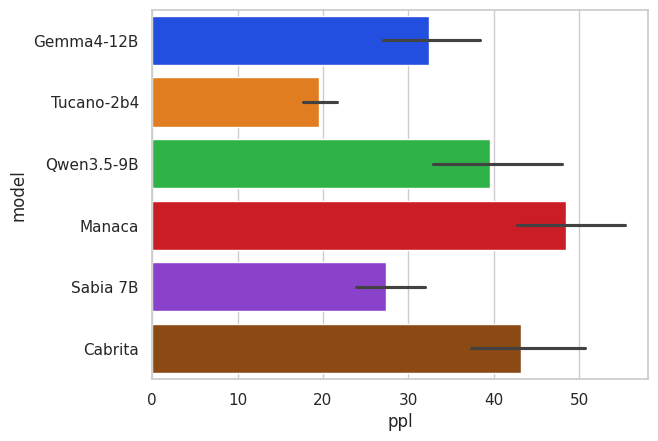

In [12]:
ax = sns.barplot(ls, y="model", x="ppl", hue="model", orient='h', palette="bright")

Não consegui observar nenhuma relação dos modelos com os resultados

## GRAMMAR SWAP vs LEXICAL SWAP

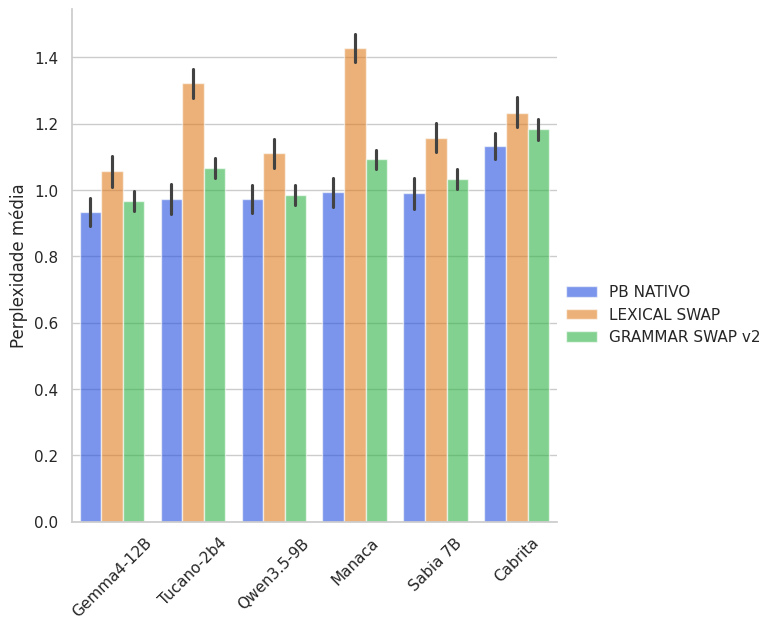

In [13]:
# plot_df = df[df["scenario"].isin(["LEXICAL SWAP", "GRAMMAR SWAP v2", "PB NATIVO"])]

plot_df = pd.concat([df[df["scenario"] == "PB NATIVO"], df[df["scenario"] == "LEXICAL SWAP"], df[df["scenario"] == "GRAMMAR SWAP v2"]])

g = sns.catplot(
    data=plot_df,
    kind="bar",
    x="model", y="bpb", 
    hue="scenario",
    estimator="mean", # errorbar="sd", 
    palette="bright", alpha=.6,height=6
)

g.set_axis_labels("", "Perplexidade média")
g.tick_params(axis='x', rotation=45)
g.legend.set_title("")

In [22]:
for model in df["model"].unique():
    print(model)

Gemma4-12B
Tucano-2b4
Qwen3.5-9B
Manaca
Sabia 7B
Cabrita


In [44]:
metric = "bpb"  

models_results = {
    "PB NATIVO": [],
    "TRANSLATION": [],
    "LEXICAL SWAP": [],
    "GRAMMAR SWAP v3": [],
    "PB CORRUPTED": [],
    "PB PERMUTED": [],
}
scenarios = list(models_results.keys())
models_results["model"] = []


for model in df["model"].unique().tolist():
    models_results["model"].append(model)

    for scenario in scenarios:
        value = df[(df["scenario"] == scenario) & (df["model"] == model)][metric].mean()
        models_results[scenario].append(value)

models_results_df = pd.DataFrame(models_results)

# Making "model" the first column
column_to_move = models_results_df.pop('model')
models_results_df.insert(0, 'model', column_to_move)

print(models_results_df.to_latex(float_format="%.2f"))

\begin{tabular}{llrrrrrr}
\toprule
 & model & PB NATIVO & TRANSLATION & LEXICAL SWAP & GRAMMAR SWAP v3 & PB CORRUPTED & PB PERMUTED \\
\midrule
0 & Gemma4-12B & 0.93 & 0.82 & 1.06 & 0.98 & 1.33 & 1.69 \\
1 & Tucano-2b4 & 0.97 & 1.08 & 1.32 & 1.08 & 1.42 & 1.82 \\
2 & Qwen3.5-9B & 0.97 & 0.84 & 1.11 & 1.00 & 1.37 & 1.73 \\
3 & Manaca & 0.99 & 1.24 & 1.43 & 1.12 & 1.37 & 1.85 \\
4 & Sabia 7B & 0.99 & 0.88 & 1.16 & 1.05 & 1.41 & 1.79 \\
5 & Cabrita & 1.13 & 0.97 & 1.23 & 1.20 & 1.57 & 1.90 \\
\bottomrule
\end{tabular}



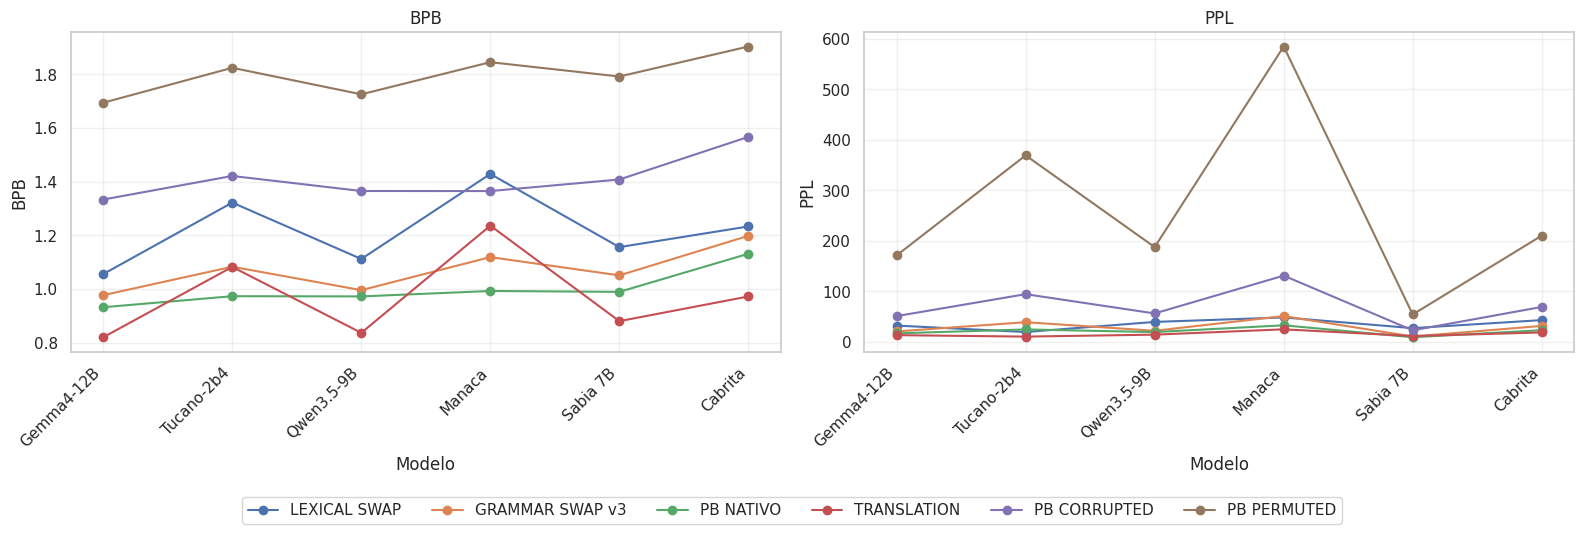

In [43]:
models = df["model"].unique()
x = range(len(models))

scenarios = [
    "LEXICAL SWAP", 
    "GRAMMAR SWAP v3", 
    "PB NATIVO", 
    "TRANSLATION", 
    "PB CORRUPTED",
    "PB PERMUTED"
]
metrics = ["bpb", "ppl"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric in zip(axes, metrics):

    for scenario in scenarios:
        y = []
        bands = []

        for model in models:
            value = df[(df["scenario"] == scenario) & (df["model"] == model)][metric]
            y.append(value.mean())
            bands.append(value.std())

        y = np.array(y)
        bands = np.array(bands)

        line, = ax.plot(x, y, marker="o", label=scenario)

        # Confidence bands
        # ax.fill_between(x, y-bands, y+bands, alpha=0.2, color=line.get_color())

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.set_xlabel("Modelo")
    ax.set_ylabel(metric.upper())
    ax.set_title(metric.upper())
    ax.grid(alpha=0.3)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(scenarios),
    bbox_to_anchor=(0.5, -0.08)
)

plt.tight_layout()
plt.show()

(Executar uma correlação para esses dados observados)

Em todos os casos, o permuted mostra sempre uma alta surpresa, mostrando que o pior cenário para todos os modelos são palavras embaralhadas e fora de ordem. Isso mostra que os modelos possuem um certo entendimento de regras gramaticais e coerência na ordem das palavras. Uma excessão é o Sabia, que possui uma perpelexidade mais próxima aos demais. Por outro lado, em relação ao BPB, os valores seguem um padrão mais estável e próximos dos outros cenários.





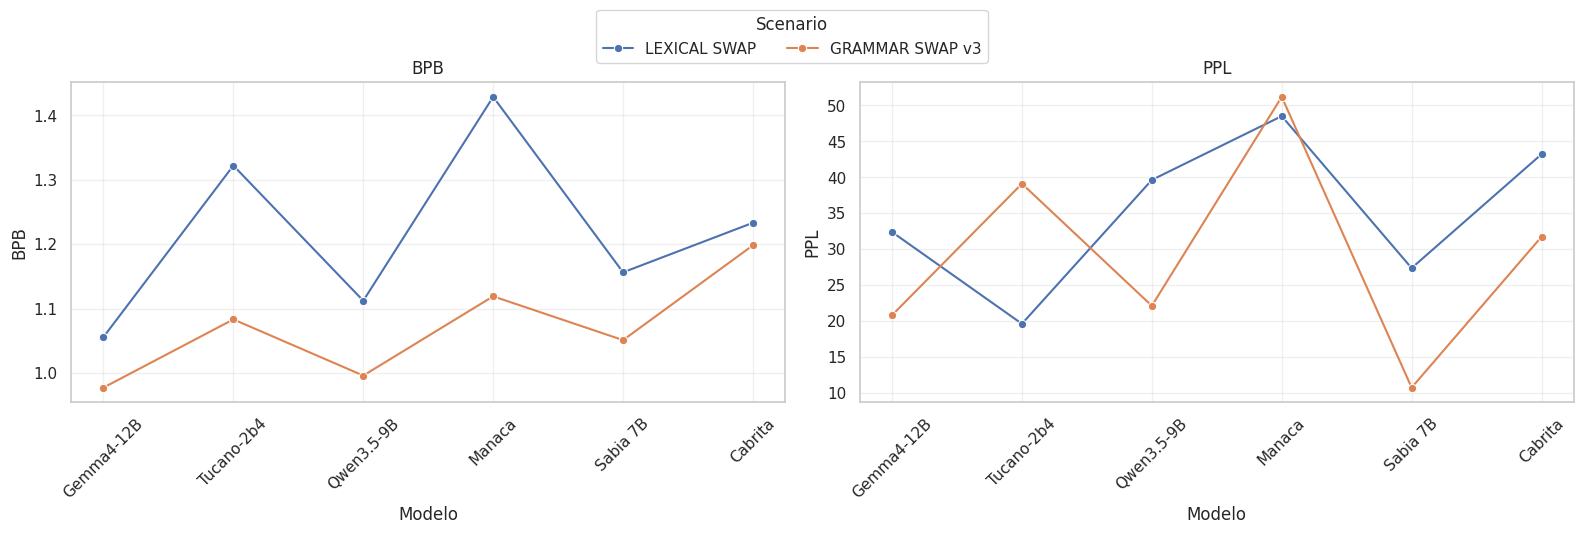

In [31]:
models = df["model"].unique()

scenarios = [
    "LEXICAL SWAP",
    "GRAMMAR SWAP v3",
    # "PB NATIVO",
    # "TRANSLATION",
    # "PB CORRUPTED"
]

metrics = ["bpb", "ppl"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric in zip(axes, metrics):

    sns.lineplot(data=df[df["scenario"].isin(scenarios)], 
        x="model", y=metric,hue="scenario",
        hue_order=scenarios,
        marker="o", estimator="mean", errorbar=None, 
        sort=False, ax=ax
    )

    ax.set_xlabel("Modelo")
    ax.set_ylabel(metric.upper())
    ax.set_title(metric.upper())
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)

# Remove a legenda individual
handles, labels = axes[0].get_legend_handles_labels()

axes[0].get_legend().remove()
axes[1].get_legend().remove()

# Legenda única para toda a figura
fig.legend(
    handles,
    labels,
    title="Scenario",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(scenarios)
)

plt.tight_layout()
plt.show()

# Gráfico de perplexidade e BPB

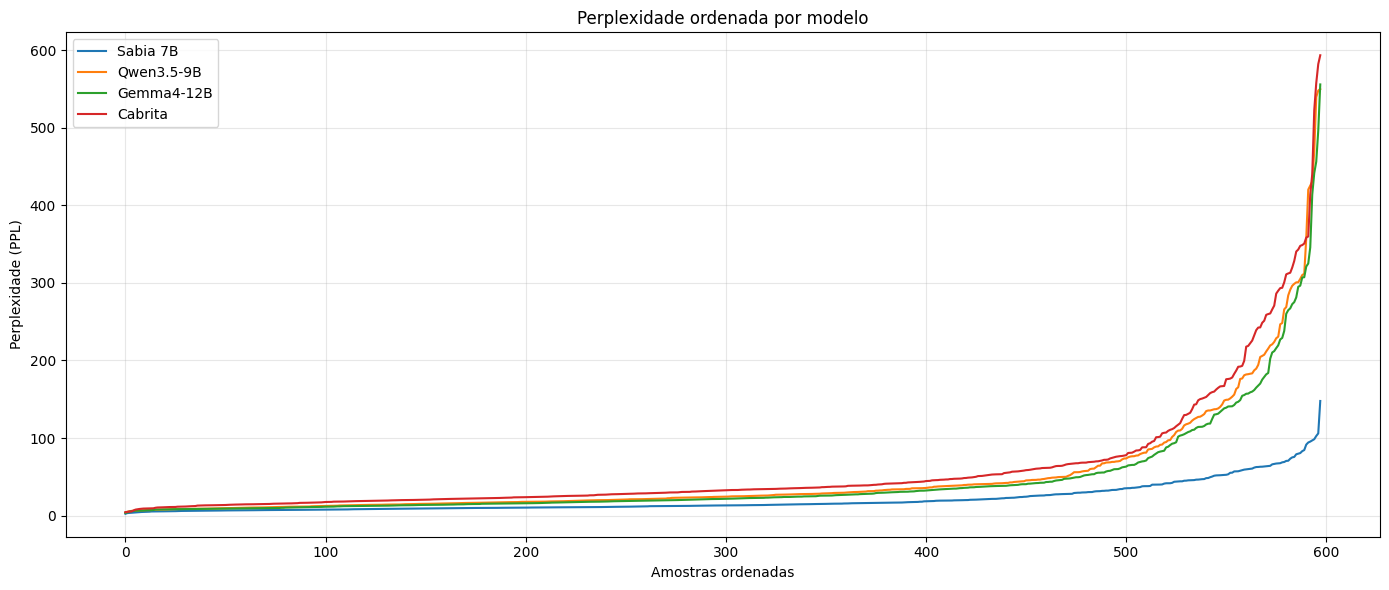

In [ ]:
plt.figure(figsize=(14, 6))

for model in ["Sabia 7B", "Qwen3.5-9B", "Gemma4-12B", "Cabrita"]:
    y = sorted(df[df["model"] == model]["ppl"].to_list())
    x = range(len(y))

    plt.plot(x, y, label=model)

plt.xlabel("Amostras ordenadas")
plt.ylabel("Perplexidade (PPL)")
plt.title("Perplexidade ordenada por modelo")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

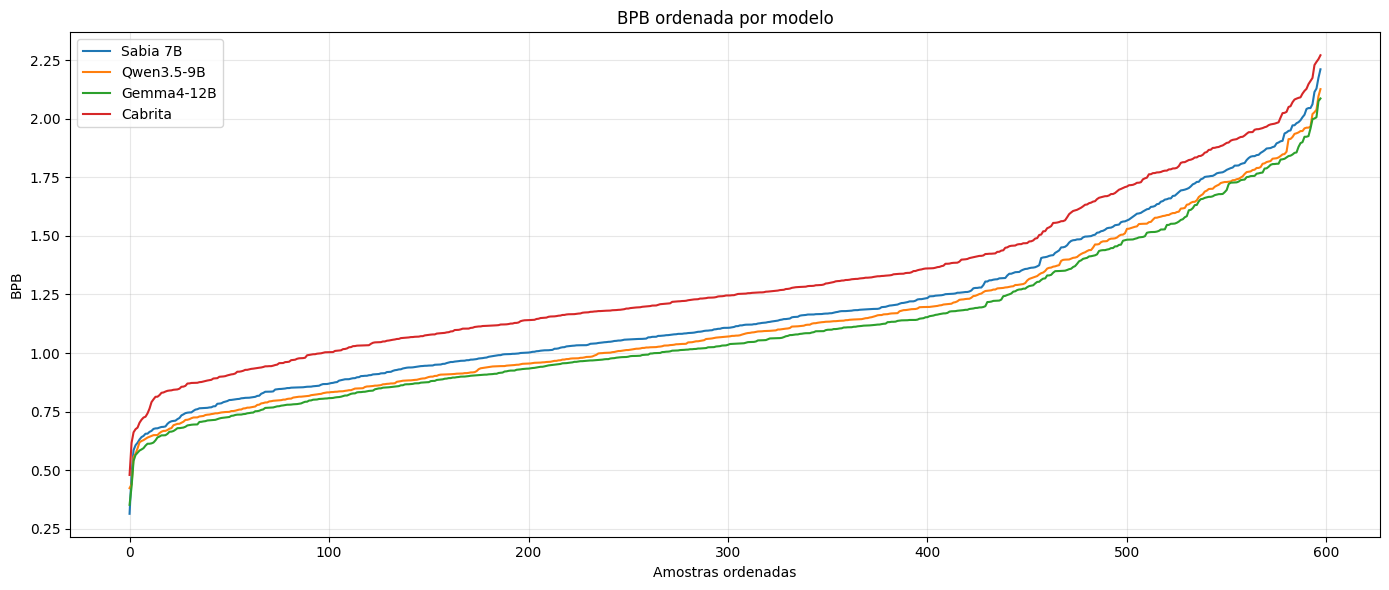

In [18]:
plt.figure(figsize=(14, 6))

for model in ["Sabia 7B", "Qwen3.5-9B", "Gemma4-12B", "Cabrita"]:
    y = sorted(df[df["model"] == model]["bpb"].to_list())
    x = range(len(y))

    plt.plot(x, y, label=model)

plt.xlabel("Amostras ordenadas")
plt.ylabel("BPB")
plt.title("BPB ordenada por modelo")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()